# Análisis descriptivo del dataset Spider para Text-to-SQL

Este notebook realiza una exploración del conjunto de datos **Spider 1.0**, utilizado ampliamente como benchmark para tareas de **Text-to-SQL**.

El objetivo es cubrir los elementos requeridos para la propuesta del proyecto:

1. Fuente y licencia.
2. Estructura y dimensiones.
3. Variables presentes y su significado.
4. Analítica descriptiva básica.
5. Representaciones gráficas.
6. Justificación del uso del dataset para el problema de Text-to-SQL.

> **Nota:** las dimensiones y estadísticas se calculan directamente a partir de la versión cargada, evitando depender únicamente de valores reportados en documentación externa.

## 1. Fuente y licencia

**Spider 1.0** fue presentado por Yu et al. en EMNLP 2018 como un benchmark de *semantic parsing* y Text-to-SQL orientado a evaluar la capacidad de generalización entre distintos dominios y esquemas de bases de datos.

- **Página oficial:** https://yale-lily.github.io/spider
- **Versión en Hugging Face:** https://huggingface.co/datasets/xlangai/spider
- **Licencia:** CC BY-SA 4.0.
- **Idioma:** inglés.

La versión disponible en Hugging Face contiene los *splits* `train` y `validation`. Cada registro asocia una pregunta en lenguaje natural con una consulta SQL y con el identificador de la base de datos sobre la cual debe ejecutarse.

La página oficial de Spider señala que Spider 1.0 fue construido específicamente para evaluar generalización a consultas y esquemas de bases de datos no vistos durante el entrenamiento.

In [5]:
# Si es necesario, descomentar la siguiente línea:
# !pip install -q datasets pandas matplotlib wordcloud

from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from wordcloud import WordCloud



In [ ]:
from pathlib import Path

# Guarda cada figura como PNG dentro de Proyecto/Datos/graficas_<dataset>.
# Tambi?n funciona si el directorio actual ya es Proyecto/Datos.
RUTA_DATOS = Path("Proyecto/Datos")
if not RUTA_DATOS.is_dir():
    RUTA_DATOS = Path(".")
CARPETA_GRAFICAS = RUTA_DATOS / "graficas_spider"
CARPETA_GRAFICAS.mkdir(parents=True, exist_ok=True)

def guardar_grafica(nombre_archivo):
    ruta = CARPETA_GRAFICAS / f"{nombre_archivo}.png"
    plt.savefig(ruta, dpi=300, bbox_inches="tight")
    print(f"Gr?fica guardada en: {ruta.resolve()}")


## 2. Carga del dataset

In [6]:
spider = load_dataset("xlangai/spider")

print(spider)

c:\Users\adwar\miniconda3\envs\ir\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\adwar\.cache\huggingface\hub\datasets--xlangai--spider. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\adwar\miniconda3\envs\ir\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hu

DatasetDict({
    train: Dataset({
        features: ['db_id', 'query', 'question', 'query_toks', 'query_toks_no_value', 'question_toks'],
        num_rows: 7000
    })
    validation: Dataset({
        features: ['db_id', 'query', 'question', 'query_toks', 'query_toks_no_value', 'question_toks'],
        num_rows: 1034
    })
})


In [7]:
# Convertimos los splits a DataFrame para facilitar el análisis.
train = spider["train"].to_pandas()
validation = spider["validation"].to_pandas()

train["split"] = "train"
validation["split"] = "validation"

df = pd.concat([train, validation], ignore_index=True)

print("Dimensiones train:", train.shape)
print("Dimensiones validation:", validation.shape)
print("Dimensiones totales analizadas:", df.shape)

df.head()

Dimensiones train: (7000, 7)
Dimensiones validation: (1034, 7)
Dimensiones totales analizadas: (8034, 7)


,db_id,query,question,query_toks,query_toks_no_value,question_toks,split
0,department_management,SELECT count(*) FROM head WHERE age > 56,How many heads of the departments are older th...,"[SELECT, count, (, *, ), FROM, head, WHERE, ag...","[select, count, (, *, ), from, head, where, ag...","[How, many, heads, of, the, departments, are, ...",train
1,department_management,"SELECT name , born_state , age FROM head ORD...","List the name, born state and age of the heads...","[SELECT, name, ,, born_state, ,, age, FROM, he...","[select, name, ,, born_state, ,, age, from, he...","[List, the, name, ,, born, state, and, age, of...",train
2,department_management,"SELECT creation , name , budget_in_billions ...","List the creation year, name and budget of eac...","[SELECT, creation, ,, name, ,, budget_in_billi...","[select, creation, ,, name, ,, budget_in_billi...","[List, the, creation, year, ,, name, and, budg...",train
3,department_management,"SELECT max(budget_in_billions) , min(budget_i...",What are the maximum and minimum budget of the...,"[SELECT, max, (, budget_in_billions, ), ,, min...","[select, max, (, budget_in_billions, ), ,, min...","[What, are, the, maximum, and, minimum, budget...",train
4,department_management,SELECT avg(num_employees) FROM department WHER...,What is the average number of employees of the...,"[SELECT, avg, (, num_employees, ), FROM, depar...","[select, avg, (, num_employees, ), from, depar...","[What, is, the, average, number, of, employees...",train


## 3. Estructura y variables

Las variables principales de Spider son:


In [8]:
# Tipos de datos y valores faltantes
display(df.dtypes.to_frame("tipo"))

faltantes = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2)
})

display(faltantes)

,tipo
db_id,str
query,str
question,str
query_toks,object
query_toks_no_value,object
question_toks,object
split,str


,faltantes,porcentaje
db_id,0,0.0
query,0,0.0
question,0,0.0
query_toks,0,0.0
query_toks_no_value,0,0.0
question_toks,0,0.0
split,0,0.0


In [9]:
# Resumen de dimensiones y cardinalidad
resumen = pd.DataFrame({
    "métrica": [
        "Número total de ejemplos",
        "Ejemplos de entrenamiento",
        "Ejemplos de validación",
        "Número de bases de datos distintas",
        "Preguntas únicas",
        "Consultas SQL únicas"
    ],
    "valor": [
        len(df),
        len(train),
        len(validation),
        df["db_id"].nunique(),
        df["question"].nunique(),
        df["query"].nunique()
    ]
})

display(resumen)

,métrica,valor
0,Número total de ejemplos,8034
1,Ejemplos de entrenamiento,7000
2,Ejemplos de validación,1034
3,Número de bases de datos distintas,160
4,Preguntas únicas,7990
5,Consultas SQL únicas,4525


## 4. Ingeniería de variables para el análisis

In [10]:
# Longitudes en palabras.
df["question_words"] = df["question"].fillna("").str.split().str.len()
df["sql_words"] = df["query"].fillna("").str.split().str.len()

# Longitudes en caracteres.
df["question_chars"] = df["question"].fillna("").str.len()
df["sql_chars"] = df["query"].fillna("").str.len()

df[[
    "question_words",
    "sql_words",
    "question_chars",
    "sql_chars"
]].describe().round(2)

,question_words,sql_words,question_chars,sql_chars
count,8034.00,8034.00,8034.00,8034.00
mean,12.69,15.85,70.50,109.26
std,4.33,9.37,23.76,64.33
min,3.00,4.00,16.00,18.00
25%,10.00,9.00,54.00,62.00
50%,12.00,13.00,68.00,92.00
75%,15.00,21.00,85.00,146.00
max,39.00,87.00,224.00,577.00


## 5. Frecuencias de categorías relevantes

In [11]:
# Bases de datos con mayor cantidad de ejemplos.
top_db = df["db_id"].value_counts().head(20)

display(top_db.to_frame("frecuencia"))

,frecuencia
db_id,
college_2,170
college_1,164
hr_1,124
world_1,120
store_1,112
soccer_2,106
bike_1,104
music_1,100
hospital_1,100


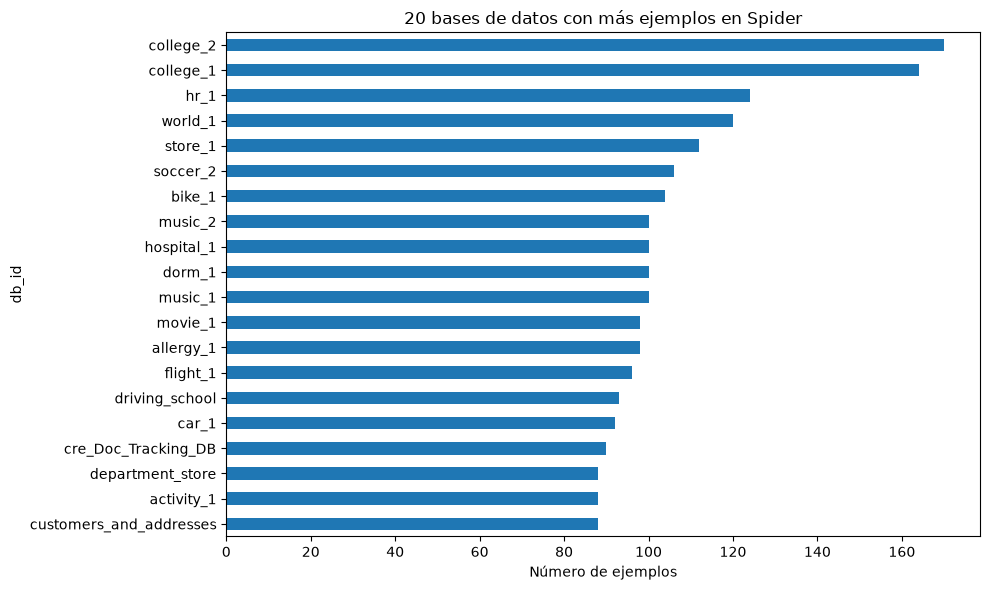

In [12]:
plt.figure(figsize=(10, 6))
top_db.sort_values().plot(kind="barh")
plt.title("20 bases de datos con más ejemplos en Spider")
plt.xlabel("Número de ejemplos")
plt.ylabel("db_id")
plt.tight_layout()
guardar_grafica("01_top_bases_datos")
plt.show()

### Frecuencia de construcciones SQL

Además de contar categorías nominales, es útil estudiar qué estructuras aparecen en las consultas SQL. Esto permite aproximarse a la complejidad sintáctica del benchmark.

Se consideran, entre otras:

- `JOIN`
- `GROUP BY`
- `ORDER BY`
- `HAVING`
- `DISTINCT`
- `LIMIT`
- agregaciones (`COUNT`, `SUM`, `AVG`, `MIN`, `MAX`)
- subconsultas.

In [13]:
def sql_features(sql):
    s = str(sql).upper()
    return {
        "JOIN": bool(re.search(r"\bJOIN\b", s)),
        "GROUP BY": bool(re.search(r"\bGROUP\s+BY\b", s)),
        "ORDER BY": bool(re.search(r"\bORDER\s+BY\b", s)),
        "HAVING": bool(re.search(r"\bHAVING\b", s)),
        "DISTINCT": bool(re.search(r"\bDISTINCT\b", s)),
        "LIMIT": bool(re.search(r"\bLIMIT\b", s)),
        "UNION": bool(re.search(r"\bUNION\b", s)),
        "INTERSECT": bool(re.search(r"\bINTERSECT\b", s)),
        "EXCEPT": bool(re.search(r"\bEXCEPT\b", s)),
        "AGREGACIÓN": bool(re.search(r"\b(COUNT|SUM|AVG|MIN|MAX)\s*\(", s)),
        # Una aproximación sencilla: más de un SELECT indica subconsulta
        "SUBCONSULTA": len(re.findall(r"\bSELECT\b", s)) > 1,
    }

features = df["query"].apply(sql_features).apply(pd.Series)
sql_freq = features.sum().sort_values(ascending=False)

display(sql_freq.to_frame("número_de_consultas"))

,número_de_consultas
AGREGACIÓN,3821
JOIN,3179
GROUP BY,2052
ORDER BY,1865
LIMIT,1296
SUBCONSULTA,1178
DISTINCT,808
HAVING,506
INTERSECT,290
EXCEPT,240


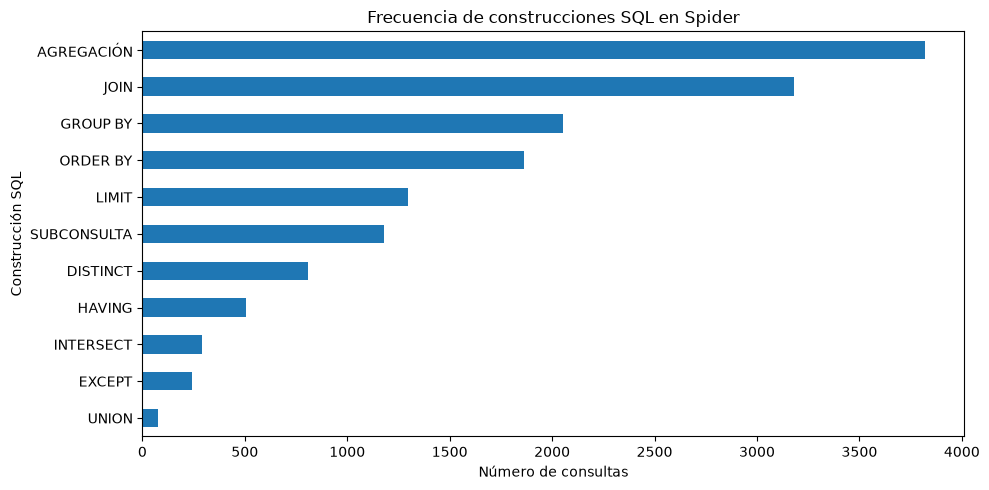

In [14]:
plt.figure(figsize=(10, 5))
sql_freq.sort_values().plot(kind="barh")
plt.title("Frecuencia de construcciones SQL en Spider")
plt.xlabel("Número de consultas")
plt.ylabel("Construcción SQL")
plt.tight_layout()
guardar_grafica("02_construcciones_sql")
plt.show()

## 6. Histogramas de longitud

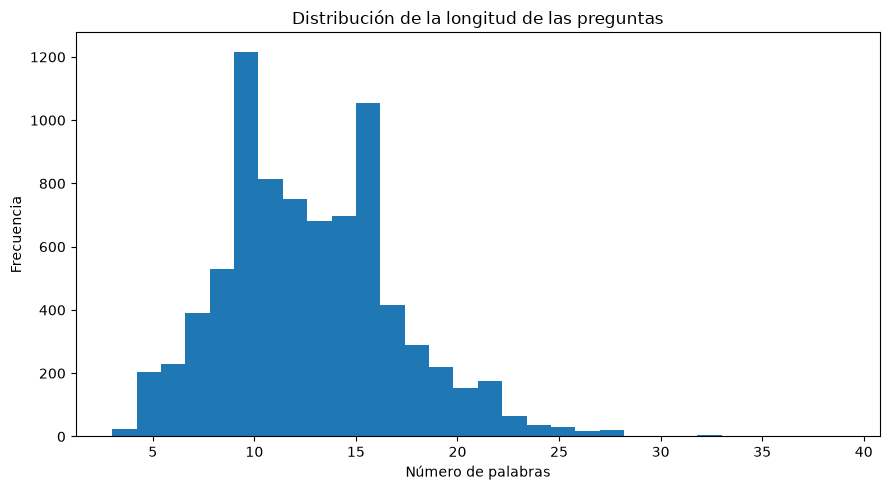

In [15]:
plt.figure(figsize=(9, 5))
plt.hist(df["question_words"], bins=30)
plt.title("Distribución de la longitud de las preguntas")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.tight_layout()
guardar_grafica("03_longitud_preguntas")
plt.show()

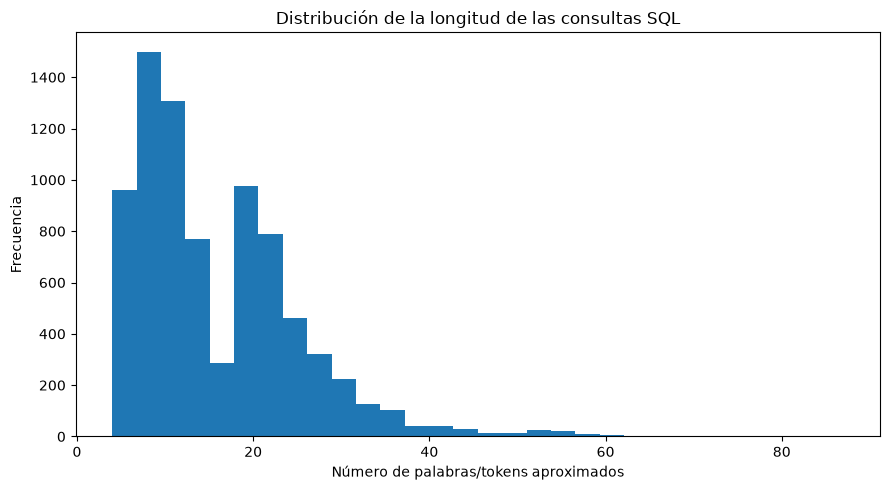

In [16]:
plt.figure(figsize=(9, 5))
plt.hist(df["sql_words"], bins=30)
plt.title("Distribución de la longitud de las consultas SQL")
plt.xlabel("Número de palabras/tokens aproximados")
plt.ylabel("Frecuencia")
plt.tight_layout()
guardar_grafica("04_longitud_sql")
plt.show()

## 7. Relación entre longitud de pregunta y longitud de SQL

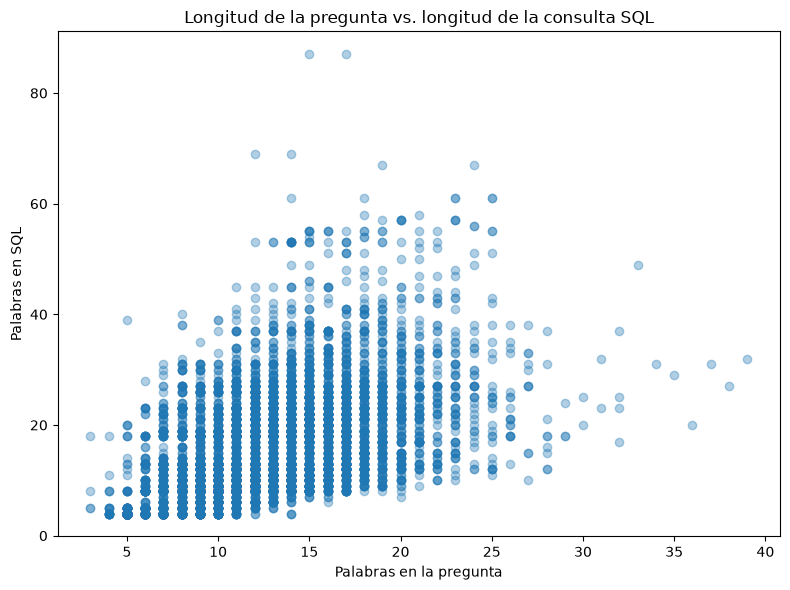

Correlación de Pearson: 0.522


In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(df["question_words"], df["sql_words"], alpha=0.35)
plt.title("Longitud de la pregunta vs. longitud de la consulta SQL")
plt.xlabel("Palabras en la pregunta")
plt.ylabel("Palabras en SQL")
plt.tight_layout()
guardar_grafica("05_pregunta_vs_sql")
plt.show()

correlacion = df[["question_words", "sql_words"]].corr().iloc[0, 1]
print(f"Correlación de Pearson: {correlacion:.3f}")

## 8. Nube de palabras de las preguntas

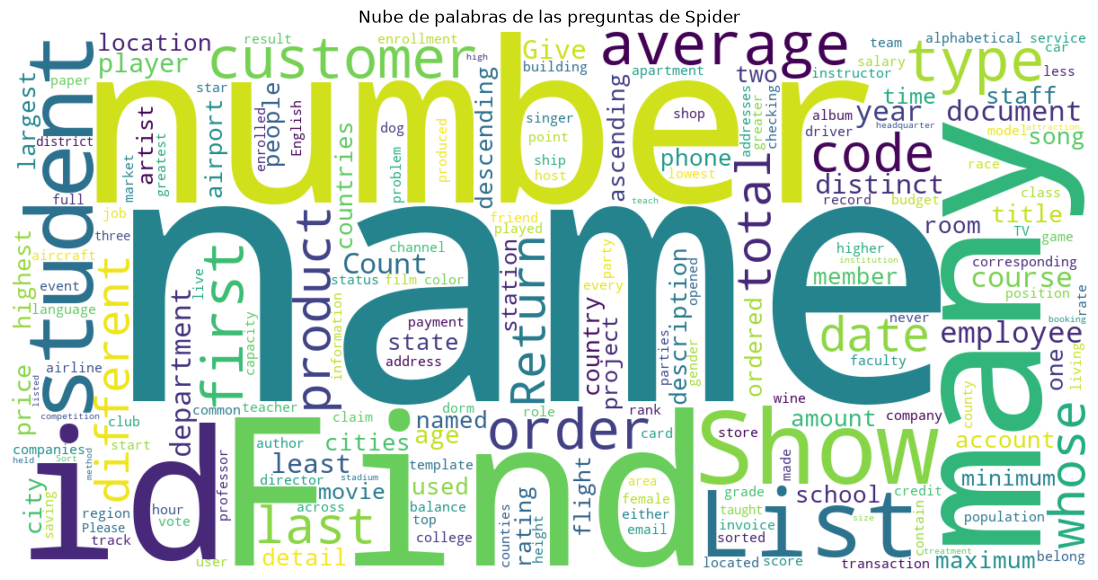

In [18]:
texto_preguntas = " ".join(df["question"].dropna().astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False
).generate(texto_preguntas)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de las preguntas de Spider")
guardar_grafica("06_nube_palabras")
plt.show()

## 9. Palabras más frecuentes en las preguntas

,palabra,frecuencia
0,name,1766
1,names,1738
2,number,1368
3,find,1238
4,show,898
5,each,801
6,list,738
7,most,694
8,average,588
9,students,537


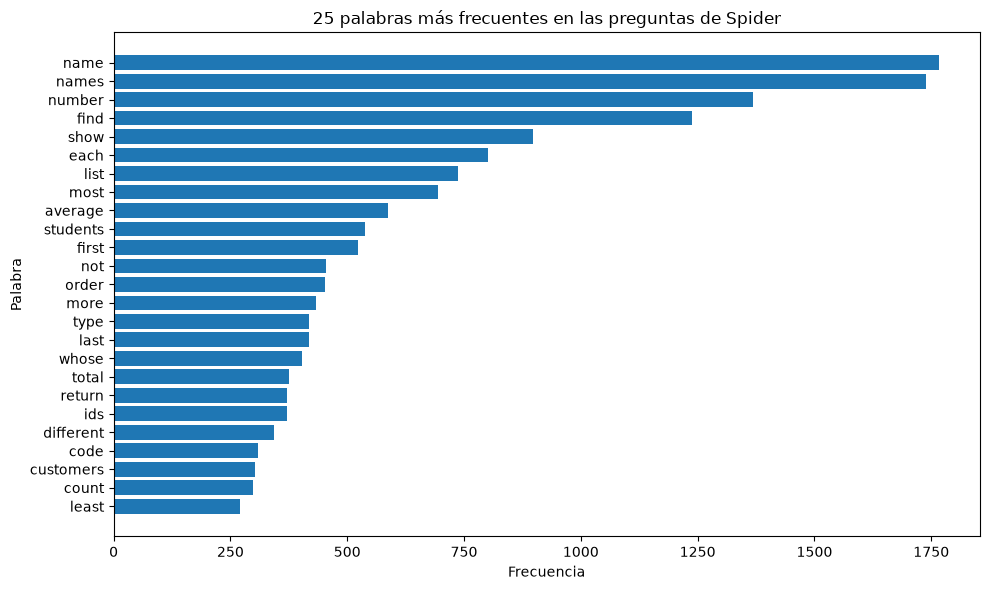

In [19]:
# Lista pequeña de stopwords en inglés para un análisis exploratorio.
stopwords = {
    "the", "a", "an", "of", "in", "on", "to", "and", "is", "are", "was", "were",
    "what", "which", "who", "how", "many", "for", "with", "from", "that", "have",
    "has", "do", "does", "all", "their", "than", "by", "be", "as", "there"
}

tokens = re.findall(r"[A-Za-z]+", texto_preguntas.lower())
tokens = [t for t in tokens if t not in stopwords and len(t) > 2]

freq = Counter(tokens).most_common(25)
freq_df = pd.DataFrame(freq, columns=["palabra", "frecuencia"])
display(freq_df)

plt.figure(figsize=(10, 6))
plt.barh(freq_df["palabra"][::-1], freq_df["frecuencia"][::-1])
plt.title("25 palabras más frecuentes en las preguntas de Spider")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.tight_layout()
guardar_grafica("07_frecuencia_palabras")
plt.show()

## 10. Comparación entre entrenamiento y validación

Una característica importante de Spider es su diseño orientado a la generalización entre esquemas. Por ello resulta útil observar qué bases aparecen en cada partición y si existe solapamiento entre ellas.

In [20]:
db_train = set(train["db_id"].unique())
db_val = set(validation["db_id"].unique())

print("Bases distintas en train:", len(db_train))
print("Bases distintas en validation:", len(db_val))
print("Bases compartidas:", len(db_train.intersection(db_val)))

print("\nEjemplos de bases solo en validation:")
print(sorted(db_val - db_train)[:20])

Bases distintas en train: 140
Bases distintas en validation: 20
Bases compartidas: 0

Ejemplos de bases solo en validation:
['battle_death', 'car_1', 'concert_singer', 'course_teach', 'cre_Doc_Template_Mgt', 'dog_kennels', 'employee_hire_evaluation', 'flight_2', 'museum_visit', 'network_1', 'orchestra', 'pets_1', 'poker_player', 'real_estate_properties', 'singer', 'student_transcripts_tracking', 'tvshow', 'voter_1', 'world_1', 'wta_1']


## 11. Justificación del uso de Spider

Spider es adecuado para este proyecto porque representa directamente el problema de **Text-to-SQL**: cada ejemplo contiene una pregunta en lenguaje natural, una consulta SQL objetivo y el identificador del esquema sobre el cual debe formularse la consulta.

Además, su carácter **multi-dominio** permite evaluar si un modelo aprende únicamente patrones asociados con bases conocidas o si es capaz de transferir el conocimiento adquirido a esquemas diferentes. Esto es especialmente relevante en sistemas basados en modelos de lenguaje, donde uno de los retos centrales es realizar correctamente el *schema linking* y producir consultas ejecutables sin depender de haber observado previamente la misma base de datos.

El análisis anterior permite estudiar no solo el tamaño del conjunto, sino también la diversidad de bases y la complejidad aproximada de las consultas mediante construcciones como agregaciones, agrupamientos, ordenamientos y subconsultas.

Por estas razones, Spider puede utilizarse tanto como conjunto de entrenamiento como benchmark para estudiar **generalización estructural, generación SQL y razonamiento sobre esquemas**.

## Referencias

- Yu, T. et al. (2018). *Spider: A Large-Scale Human-Labeled Dataset for Complex and Cross-Domain Semantic Parsing and Text-to-SQL Task*. EMNLP.
- Página oficial: https://yale-lily.github.io/spider
- Hugging Face: https://huggingface.co/datasets/xlangai/spider

## Análisis e interpretación de las gráficas

Las visualizaciones resumen la variedad de dominios, las preguntas y las estructuras SQL presentes en los 8.034 registros analizados de Spider.

- **Distribución por base de datos:** los ejemplos cubren 160 bases, con distinta representación. `college_2` (170 ejemplos), `college_1` (164) y `hr_1` (124) son las más frecuentes entre las 20 mostradas. La distribución refleja diversidad de esquemas, aunque no es uniforme.
- **Construcciones SQL:** hay agregaciones en 3.821 consultas y `JOIN` en 3.179. También son frecuentes `GROUP BY` (2.052), `ORDER BY` (1.865), `LIMIT` (1.296) y subconsultas (1.178). `INTERSECT` (290), `EXCEPT` (240) y `UNION` (78) aparecen menos. Las categorías pueden coincidir en una misma consulta.
- **Longitudes:** las preguntas tienen una media de 12,69 palabras y las consultas SQL de 15,85. Los histogramas muestran dispersión y una cola de ejemplos más largos; los máximos son 39 palabras para preguntas y 87 para SQL, usando separación por espacios.
- **Relación entre longitudes:** la correlación de Pearson entre el número de palabras de la pregunta y el de la consulta es 0,522. La asociacion positiva indica que preguntas más extensas tienden a asociarse con SQL más largo, aunque la longitud no basta para anticipar la complejidad.
- **Nube y frecuencia de palabras:** destacan *name*, *names*, *number*, *find*, *show* y *each*, compatibles con solicitudes de busqueda, listado y conteo. Estas frecuencias son descriptivas y no identifican por si solas la intencion semantica.

Spider tiene particiones sin bases compartidas: 140 bases en entrenamiento y 20 en validación. En conjunto, la distribución por bases y las construcciones SQL respaldan su uso para estudiar generación SQL y generalizacion entre esquemas. Los conteos de construcciones representan presencia y no categorías excluyentes.